In [1]:
import pandas as pd

sentiment = pd.read_csv('fear_greed_index.csv')   # match your actual filename
trades = pd.read_csv('historical_data.csv') # match your actual filename

print(sentiment.head())
print(sentiment.columns)
print(trades.head())
print(trades.columns)

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      

In [2]:
# Convert trades timestamp to date
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%d')

# Merge trades with sentiment on date
merged = trades.merge(sentiment[['date', 'classification']], on='date', how='left')

print(merged[['date', 'classification']].head(10))
print("\nMissing sentiment matches:", merged['classification'].isna().sum(), "out of", len(merged))

         date classification
0  2024-12-02  Extreme Greed
1  2024-12-02  Extreme Greed
2  2024-12-02  Extreme Greed
3  2024-12-02  Extreme Greed
4  2024-12-02  Extreme Greed
5  2024-12-02  Extreme Greed
6  2024-12-02  Extreme Greed
7  2024-12-02  Extreme Greed
8  2024-12-02  Extreme Greed
9  2024-12-02  Extreme Greed

Missing sentiment matches: 6 out of 18608


In [3]:
# 1. Average Closed PnL by sentiment
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].agg(['mean', 'sum', 'count']).sort_values('mean', ascending=False)
print("PnL by Sentiment:\n", pnl_by_sentiment)

# 2. Win rate by sentiment (% of trades with positive PnL)
merged['is_win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('classification')['is_win'].mean().sort_values(ascending=False)
print("\nWin Rate by Sentiment:\n", win_rate)

# 3. Average trade size (USD) by sentiment
size_by_sentiment = merged.groupby('classification')['Size USD'].mean().sort_values(ascending=False)
print("\nAvg Trade Size (USD) by Sentiment:\n", size_by_sentiment)

# 4. Leverage / direction split by sentiment (Buy vs Sell)
direction_by_sentiment = merged.groupby(['classification', 'Direction']).size().unstack(fill_value=0)
print("\nDirection counts by Sentiment:\n", direction_by_sentiment)

PnL by Sentiment:
                       mean           sum  count
classification                                 
Extreme Fear    338.916162  2.531704e+05    747
Fear            194.770442  1.638799e+06   8414
Neutral         178.839679  5.558337e+05   3108
Greed           136.216495  6.445765e+05   4732
Extreme Greed    65.938570  1.055017e+05   1600

Win Rate by Sentiment:
 classification
Neutral          0.542618
Fear             0.415617
Greed            0.350380
Extreme Fear     0.322624
Extreme Greed    0.115000
Name: is_win, dtype: float64

Avg Trade Size (USD) by Sentiment:
 classification
Fear             30507.735890
Greed            28036.998658
Neutral          25814.644156
Extreme Greed     8437.322281
Extreme Fear      7681.766118
Name: Size USD, dtype: float64

Direction counts by Sentiment:
 Direction       Auto-Deleveraging  Buy  Close  Close Long  Close Short  \
classification                                                           
Extreme Fear                    

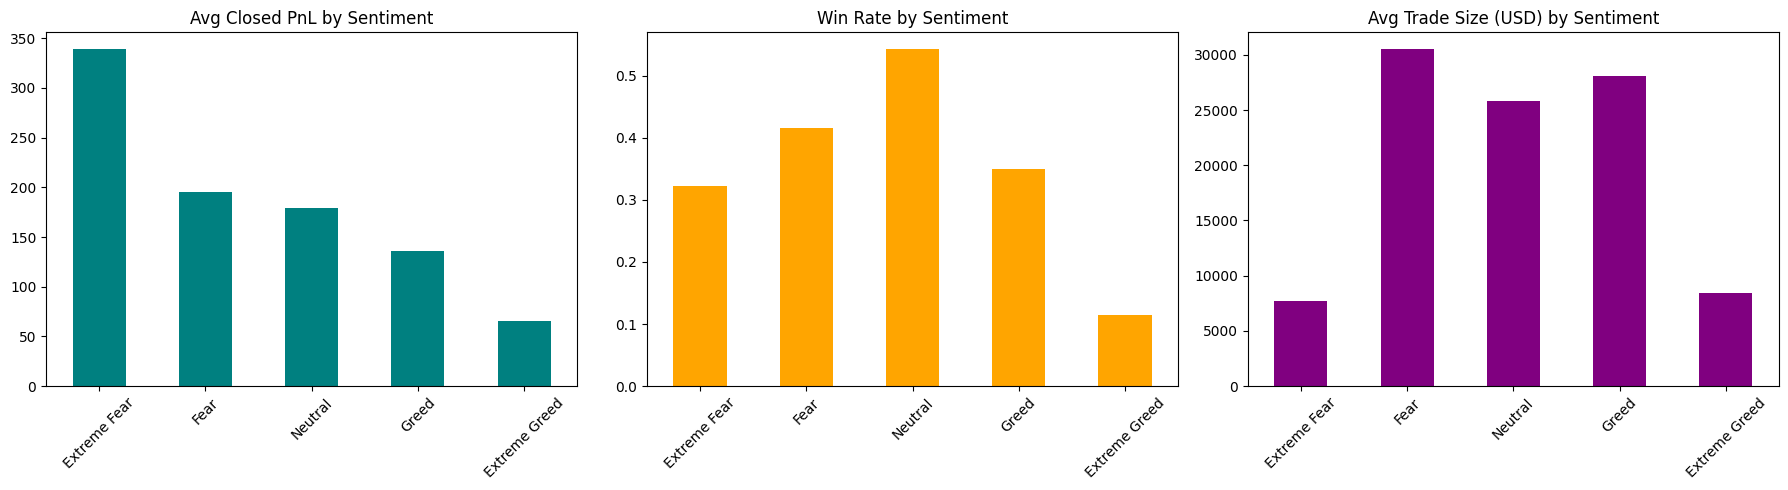

In [4]:
import matplotlib.pyplot as plt

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pnl_by_sentiment.loc[order]['mean'].plot(kind='bar', ax=axes[0], color='teal', title='Avg Closed PnL by Sentiment')
win_rate.loc[order].plot(kind='bar', ax=axes[1], color='orange', title='Win Rate by Sentiment')
size_by_sentiment.loc[order].plot(kind='bar', ax=axes[2], color='purple', title='Avg Trade Size (USD) by Sentiment')

for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150)
plt.show()